# Scratch detection on glass surfaces

Classical image-processing pipeline that turns raw glass images into **binary scratch masks** to be used later as ground-truth labels `Y` for a U-Net.

**Convention used everywhere in this notebook:**

| pixel value | meaning |
|---|---|
| `255` (white) | scratch |
| `0`   (black) | background / dust / noise |

Pipeline:

$$
I_{raw} \;\longrightarrow\; \text{preprocess} \;\longrightarrow\; \text{threshold} \;\longrightarrow\; \text{morphology} \;\longrightarrow\; \text{component filter} \;\longrightarrow\; M_{final}
$$

Every saved mask has the **same filename and same shape** as its source image.

**Polarity-aware:** controlled by `Params.bright_features`. Set it to `True` when scratches are *bright on dark glass* (e.g. specular reflections on a dark sample) and `False` when scratches are *dark on bright glass* (classical transmission lighting). Every operator and threshold below honors this flag.

## 1. Project setup

In [72]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional

# scikit-image provides the multi-scale ridge (Frangi) filter and hysteresis thresholding
# that classical CV tools (top-hat + Otsu) struggle to replicate for faint thin scratches.
from skimage.filters import frangi as _frangi
from skimage.filters import apply_hysteresis_threshold as _hysteresis
# Skeletonize each component down to a 1-px centreline. Its length relative to the
# stroke width is the most orientation- and curvature-robust "thin line vs compact
# blob" discriminator we have — used in §5.2 to drop dust grains that survive the
# bbox/ellipse gate on a noisy elongation estimate.
from skimage.morphology import skeletonize as _skeletonize

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['image.cmap'] = 'gray'

In [73]:
# Dataset folders. Edit ROOT to point at wherever your data lives.
ROOT = Path('data_1')

RAW_DIR        = ROOT / 'raw_images'
MASKS_DIR      = ROOT / 'generated_masks'
DEBUG_DIR      = ROOT / 'debug_outputs'
TILES_IMG_DIR  = ROOT / 'tiles_images'
TILES_MASK_DIR = ROOT / 'tiles_masks'

for d in (RAW_DIR, MASKS_DIR, DEBUG_DIR, TILES_IMG_DIR, TILES_MASK_DIR):
    d.mkdir(parents=True, exist_ok=True)

IMG_EXTS = ('.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp')

def list_images(folder: Path):
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in IMG_EXTS])

print('raw images found:', len(list_images(RAW_DIR)))

raw images found: 1


## 8. Parameter tuning (defined early so every later cell can use it)

Put it at the top so you can sweep parameters without scrolling. Pass a `Params` instance into every pipeline function — no hidden globals.

Each knob is a coefficient in the formulas of §3–§5. The comments next to each field point at the corresponding equation.

In [74]:
@dataclass
class Params:
    # ----------------------------------------------------------------
    # Polarity — the single most important flag.
    # True  : scratches are BRIGHTER than the glass (e.g. specular highlights on dark glass).
    #         → white top-hat, D = max(0, I - B), no inversion before threshold.
    # False : scratches are DARKER than the glass (transmission-light setup).
    #         → black-hat, D = max(0, B - I), invert before threshold.
    # ----------------------------------------------------------------
    bright_features: bool = True

    # --- preprocessing ---
    gaussian_ksize: int = 10
    # Bumped 3 → 5: a wider median pre-smooths dust grains so adaptive thresholding
    # has less salt-and-pepper to chew on. 1-2 px wide scratches still survive because
    # median has a 50 % breakdown — a 5x5 window still has > half its pixels along the
    # scratch when the scratch runs through it.
    median_ksize:   int = 5
    clahe_clip:     float = 3.0
    clahe_tile:     int   = 8
    bg_subtract_ksize: int = 51
    tophat_ksize:   int = 15

    # --- ridge (Frangi) filter ---
    frangi_sigmas: tuple = (1.0, 2.0, 3.0, 4.0)
    frangi_alpha:  float = 0.5
    frangi_beta:   float = 0.5
    frangi_gamma:  float = 5.0

    # --- thresholding ---
    # 'fixed' | 'otsu' | 'adaptive' | 'tophat_otsu' | 'bgsub_otsu'
    # 'ridge_otsu' | 'ridge_hysteresis' | 'hysteresis'
    # Default was 'otsu', but it FLOODS on glasses with uneven illumination / surface
    # texture (§13): the intensity histogram has no clean valley, so Otsu marks huge
    # regions as foreground — B/img__13 and C/img__10 ballooned to ~190k mask px of
    # noise. Switched to 'ridge_hysteresis': the Frangi response keys on line SHAPE
    # (Hessian eigenvalue ratios), not absolute brightness, so it stays clean under
    # uneven lighting (those two images drop to ~4k / 14k px) while still tracing thin
    # scratches. See §13 for the side-by-side that motivated this.
    threshold_method: str = 'ridge_hysteresis'
    fixed_thresh:     int = 30
    # 31 → 51: wider local-mean window so dust grains are no longer their own local
    # maximum (they get averaged with neighbour pixels and fall below T = mean - C).
    # Scratches, being long, still have a 'dark' surround over the larger window.
    adaptive_block:   int = 51
    adaptive_C:       int = -5

    # Hysteresis cutoffs as FRACTIONS of the per-image peak Frangi response: seeds are
    # pixels above hyst_high, grown into any pixel above hyst_low that is 8-connected to
    # a seed. Loosened 0.05/0.20 → 0.03/0.12: the §13 sweep showed the tighter pair
    # missed faint scratches (A/img__57 recovered only 19 components vs 46 at 0.03/0.12)
    # while the looser pair STILL kept the noisy glasses clean (B/img__13 ~4k px,
    # C/img__10 ~14k px, vs Otsu's ~190k). Drop toward 0.02/0.08 for even higher recall
    # if faint scratches still go missing, at the cost of a little more speckle.
    hyst_low:  float = 0.03
    hyst_high: float = 0.12

    # --- morphology ---
    # 2 → 3: a 3×3 opening removes 1-2 px speckles (dust dots in the candidate mask)
    # entirely. Real scratches are typically 8+ px long and at least 1-2 px wide,
    # so a 3×3 erosion still leaves enough body to be re-grown by dilation.
    open_ksize:  int = 3
    close_ksize: int = 3

    # --- connected-component filter (scratch = long, thin, elongated) ---
    # The §5 gate combines aspect and elongation with OR (not AND): when scratches
    # cross or are surrounded by dust they form clusters with a wide bbox (low aspect)
    # even though the fitted ellipse is still strongly elongated, and vice versa.
    # Either passing is enough.
    # min_elongation 2.0 → 1.5: admits faint scratch fragments where the ellipse fit
    # is noisy (analysis of img__0 showed 11 components rejected only because elong
    # sat in the 1.4-1.99 range — all of them visually real scratches).
    # max_solidity 0.95 → 1.10: solidity = area / |hull|, which for very thin curves
    # is ≈ 1 and can numerically exceed 1 due to OpenCV's rounding (contour_area can
    # be slightly larger than the integer-precision hull area). Capping above 1
    # admits the 81 long thin curved scratches that were the largest reject bucket.
    min_area:         int   = 30
    max_area:         int   = 200_000
    min_length:       int   = 8
    min_aspect_ratio: float = 2.0
    min_elongation:   float = 1.5
    max_solidity:     float = 1.10
    # min_slenderness — skeleton-based dust gate, ANDed on top of the OR above.
    # slenderness = skel_len / mean_stroke_width = skel_len**2 / area, i.e. how many
    # stroke-widths long the 1-px centreline is. A scratch is a long centreline over a
    # thin stroke → high score; a dust grain is a compact blob whose skeleton collapses
    # to a short stub → score < ~1, even when a noisy fitted-ellipse elongation let it
    # pass the OR gate. This is the one gate that does NOT trust the ellipse fit.
    # Measured on img__0: kept scratches median slender 5.3 (5th-pct 1.2); rejected
    # dust (area>=30) median 0.4. A floor of 1.5 prunes the 8 chunkiest survivors
    # (width 8-17 px, skel 9-19 px) on ellipse noise while keeping 84/92 real scratch
    # components. Lower toward 1.0 if it starts eating faint short scratches; raise
    # toward 2.0 to be stricter about dust.
    min_slenderness:  float = 1.5

P = Params()
P

Params(bright_features=True, gaussian_ksize=10, median_ksize=5, clahe_clip=3.0, clahe_tile=8, bg_subtract_ksize=51, tophat_ksize=15, frangi_sigmas=(1.0, 2.0, 3.0, 4.0), frangi_alpha=0.5, frangi_beta=0.5, frangi_gamma=5.0, threshold_method='ridge_hysteresis', fixed_thresh=30, adaptive_block=51, adaptive_C=-5, hyst_low=0.03, hyst_high=0.12, open_ksize=3, close_ksize=3, min_area=30, max_area=200000, min_length=8, min_aspect_ratio=2.0, min_elongation=1.5, max_solidity=1.1, min_slenderness=1.5)

## 2. Load and visualize images

Grayscale is enough: scratches on glass are an *intensity* signature (a thin bright or dark line), not a color one. Working in one channel halves memory and lets every later operator be a scalar transform $I \colon \mathbb{Z}^2 \to [0, 255]$.

In [75]:
# Minimum connected-component area (px) for a red blob to count as a real
# pen-mark rather than chromatic noise. Measured on img__0: the actual mark is
# ~3200 px while every spurious red-tinted pixel along a scratch sits below 20,
# so 100 leaves a huge safety margin in either direction.
RED_MIN_COMPONENT_AREA = 100


def _red_mask_bgr(bgr: np.ndarray) -> np.ndarray:
    """Mask the red/orange pen-marks at the image borders.

    These are reference annotations, not scratches — if they survive into the
    grayscale image they become very bright streaks and dominate every downstream
    threshold. Two stages:

    1. HSV hue gate. Red wraps around H so union the [0, 20] and [160, 180] bands,
       requiring moderate saturation to skip dark neutral pixels.
    2. Connected-component area filter. Scratches have chromatic aberration that
       leaks a few isolated red-tinted pixels along their length — those would be
       inpainted away and erase real scratches. Keeping only components above
       RED_MIN_COMPONENT_AREA isolates the actual pen-mark.
    """
    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    low  = cv.inRange(hsv, (0,   60, 40), (20,  255, 255))
    high = cv.inRange(hsv, (160, 60, 40), (180, 255, 255))
    raw  = cv.bitwise_or(low, high)

    num, labels, stats, _ = cv.connectedComponentsWithStats(raw, connectivity=8)
    out = np.zeros_like(raw)
    for i in range(1, num):
        if stats[i, cv.CC_STAT_AREA] >= RED_MIN_COMPONENT_AREA:
            out[labels == i] = 255
    return out


def load_gray(path: Path) -> np.ndarray:
    """Load a raw photo, inpaint the red annotations, return grayscale.

    Every caller of the pipeline goes through here, so removing the red marks at
    load time means no later stage ever sees them. Inpainting (rather than
    zeroing) fills the hole with the surrounding glass texture, so the bordering
    region does not turn into a strong artificial edge that Frangi would pick up.
    """
    bgr = cv.imread(str(path), cv.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(path)
    mask = _red_mask_bgr(bgr)
    if mask.any():
        # Dilate to cover the anti-aliased halo around the mark before inpaint.
        mask = cv.dilate(mask, np.ones((5, 5), np.uint8), iterations=2)
        bgr = cv.inpaint(bgr, mask, 5, cv.INPAINT_TELEA)
    return cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)

def show(img, title='', ax=None, stretch=False):
    """Display a single-channel image.

    stretch=False : pin vmin/vmax to [0, 255] for uint8 — honest comparison of absolute intensity.
    stretch=True  : auto-scale to [img.min(), img.max()] — useful for preprocessing stages whose
                    signal lives in a small subrange (top-hat, bgsub) so it doesn't look black.
    """
    if ax is None:
        _, ax = plt.subplots()
    if stretch or img.dtype != np.uint8:
        ax.imshow(img)                      # let matplotlib pick vmin/vmax from data
    else:
        ax.imshow(img, vmin=0, vmax=255)
    ax.set_title(title)
    ax.set_axis_off()
    return ax

raw_paths = list_images(RAW_DIR)
if not raw_paths:
    print(f'No images in {RAW_DIR}. Drop your glass photos there before running the next cells.')
else:
    print(f'{len(raw_paths)} images:')
    for p in raw_paths[:10]:
        print(' ', p.name)

1 images:
  img__0.png


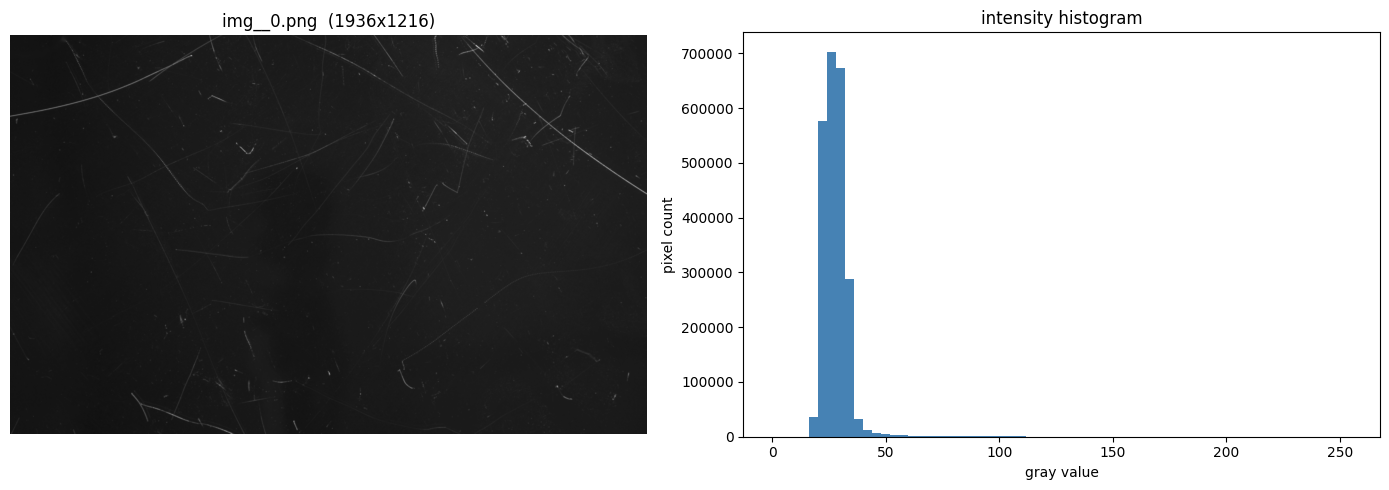

In [ ]:
# Pick one image to develop the pipeline on. Change SAMPLE_IDX to iterate.
SAMPLE_IDX = 10

sample_path = raw_paths[SAMPLE_IDX]
sample = load_gray(sample_path)

# A bimodal-looking histogram is a hint that Otsu will work well. For dark-glass images
# the histogram is heavily skewed toward 0 — pure Otsu on the raw image will under-segment.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
show(sample, f'{sample_path.name}  ({sample.shape[1]}x{sample.shape[0]})', axes[0])
axes[1].hist(sample.ravel(), bins=64, range=(0, 255), color='steelblue')
axes[1].set_title('intensity histogram')
axes[1].set_xlabel('gray value'); axes[1].set_ylabel('pixel count')
plt.tight_layout(); plt.show()

## 3. Preprocessing

We want to **enhance** scratches and **suppress** everything else (sensor noise, dust grains, slow illumination drift) *before* thresholding. Six operators:

**Gaussian blur** — convolution with an isotropic Gaussian, low-pass filter:

$$
I_g(x,y) \;=\; \sum_{i,j} I(x+i,\,y+j)\,G_\sigma(i,j),
\qquad
G_\sigma(i,j) \;=\; \frac{1}{2\pi\sigma^{2}}\exp\!\left(-\,\tfrac{i^{2}+j^{2}}{2\sigma^{2}}\right)
$$

**Median blur** — non-linear, robust to outliers (kills isolated dust grains without smearing edges):

$$
I_m(x,y) \;=\; \operatorname{median}\bigl\{\,I(x{+}i,\,y{+}j)\;:\;|i|,|j|\le k/2\,\bigr\}
$$

**CLAHE** — local histogram equalization with bin-clipping:

$$
I_c(x,y) \;=\; \bigl\lfloor 255\cdot \mathrm{CDF}_{\,\text{tile}}\bigl(I(x,y)\bigr)\bigr\rfloor
$$

**Background subtraction** — large median filter estimates the slowly-varying glass background; subtract:

$$
B \;=\; \operatorname{median}_{k\times k}(I), \qquad
D \;=\; \begin{cases} \max(0,\;I - B) & \text{if bright\_features=True}\\ \max(0,\;B - I) & \text{else}\end{cases}
$$

**Top-hat / Black-hat** — polarity-aware morphological residual:

$$
\gamma_S(I) = (I \ominus S)\oplus S, \qquad \phi_S(I) = (I \oplus S)\ominus S
$$
$$
\text{TH}_S(I) = I - \gamma_S(I) \quad (\text{bright features}), \qquad
\text{BH}_S(I) = \phi_S(I) - I \quad (\text{dark features})
$$

**Frangi ridge filter (NEW)** — multi-scale Hessian-based line detector. At each scale $\sigma$, build the Hessian of the Gaussian-smoothed image and compute its eigenvalues $|\lambda_1|\le|\lambda_2|$. A ridge-like pixel has $|\lambda_1|\approx 0$ and $|\lambda_2|\gg 0$. Define

$$
R_B = \tfrac{|\lambda_1|}{|\lambda_2|}, \qquad S = \sqrt{\lambda_1^{2} + \lambda_2^{2}}, \qquad
V_\sigma = \exp\!\left(-\tfrac{R_B^{2}}{2\beta^{2}}\right)\Bigl(1 - \exp\!\left(-\tfrac{S^{2}}{2c^{2}}\right)\Bigr)
$$

Final response $V(x,y) = \max_\sigma V_\sigma(x,y) \in [0, 1]$. A 1-px-wide faint scratch and a 4-px-wide sharp scratch both score high, provided $\sigma$ covers their widths. This is the right tool for **faint scratches** the top-hat/Otsu combo misses.

In [77]:
def to_gray(img: np.ndarray) -> np.ndarray:
    if img.ndim == 3:
        return cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    return img

def gaussian_blur(img, ksize: int):
    # I_g = I * G_σ. OpenCV picks σ from ksize when σ=0.
    if ksize and ksize >= 3:
        k = ksize if ksize % 2 == 1 else ksize + 1
        return cv.GaussianBlur(img, (k, k), 0)
    return img

def median_blur(img, ksize: int):
    # I_m(x,y) = median over a k×k neighborhood. Non-linear → preserves edges, removes specks.
    if ksize and ksize >= 3:
        k = ksize if ksize % 2 == 1 else ksize + 1
        return cv.medianBlur(img, k)
    return img

def clahe(img, clip: float, tile: int):
    op = cv.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile))
    return op.apply(img)

def background_subtract(img, ksize: int, bright_features: bool):
    """Polarity-aware: bright_features=True → D = max(0, I - B); else D = max(0, B - I).

    Pick k much larger than scratch width so the scratch is an outlier of the median
    (which has a 50 % breakdown point) and survives as a positive residual.
    cv.subtract is saturated (clips negatives at 0), which gives the max(0, ·) for free.
    """
    k = ksize if ksize % 2 == 1 else ksize + 1
    bg = cv.medianBlur(img, k)
    return cv.subtract(img, bg) if bright_features else cv.subtract(bg, img)

def tophat(img, ksize: int, bright_features: bool):
    """Polarity-aware: white top-hat for bright features, black-hat for dark features.

    Both flavours return a near-zero background with the small-scale features
    of interest lifted up to positive intensities (bright-on-dark).
    """
    se = cv.getStructuringElement(cv.MORPH_RECT, (ksize, ksize))
    op = cv.MORPH_TOPHAT if bright_features else cv.MORPH_BLACKHAT
    return cv.morphologyEx(img, op, se)

def ridge_filter(img, sigmas, alpha, beta, gamma, bright_features: bool):
    """Frangi multi-scale vesselness. Returns float32 in [0, 1].

    - sigmas         : iterable of scales σ in pixels (each scale ≈ half-width of a target ridge).
    - alpha, beta, c : weights of the eigenvalue ratios; defaults are sane for thin 2D ridges.
    - bright_features: True  → enhance BRIGHT ridges (black_ridges=False).
                       False → enhance DARK   ridges (black_ridges=True ).
    """
    f = img.astype(np.float32) / 255.0
    return _frangi(f, sigmas=sigmas, alpha=alpha, beta=beta, gamma=gamma,
                   black_ridges=not bright_features).astype(np.float32)

def preprocess(img: np.ndarray, p: Params) -> dict:
    """Return every intermediate stage in a dict — useful for debugging and tuning.

    Order matters: median BEFORE CLAHE (so CLAHE does not amplify dust),
    bg-subtract / top-hat / Frangi all operate on the CLAHE output to benefit
    from boosted local contrast on faint scratches.
    """
    gray   = to_gray(img)
    blur   = gaussian_blur(gray, p.gaussian_ksize)
    med    = median_blur(blur, p.median_ksize)
    eq     = clahe(med, p.clahe_clip, p.clahe_tile)
    bgsub  = background_subtract(eq, p.bg_subtract_ksize, p.bright_features)
    th     = tophat(eq, p.tophat_ksize, p.bright_features)
    ridge  = ridge_filter(eq, p.frangi_sigmas,
                          p.frangi_alpha, p.frangi_beta, p.frangi_gamma,
                          p.bright_features)
    return dict(gray=gray, blur=blur, median=med, clahe=eq,
                bgsub=bgsub, tophat=th, ridge=ridge)

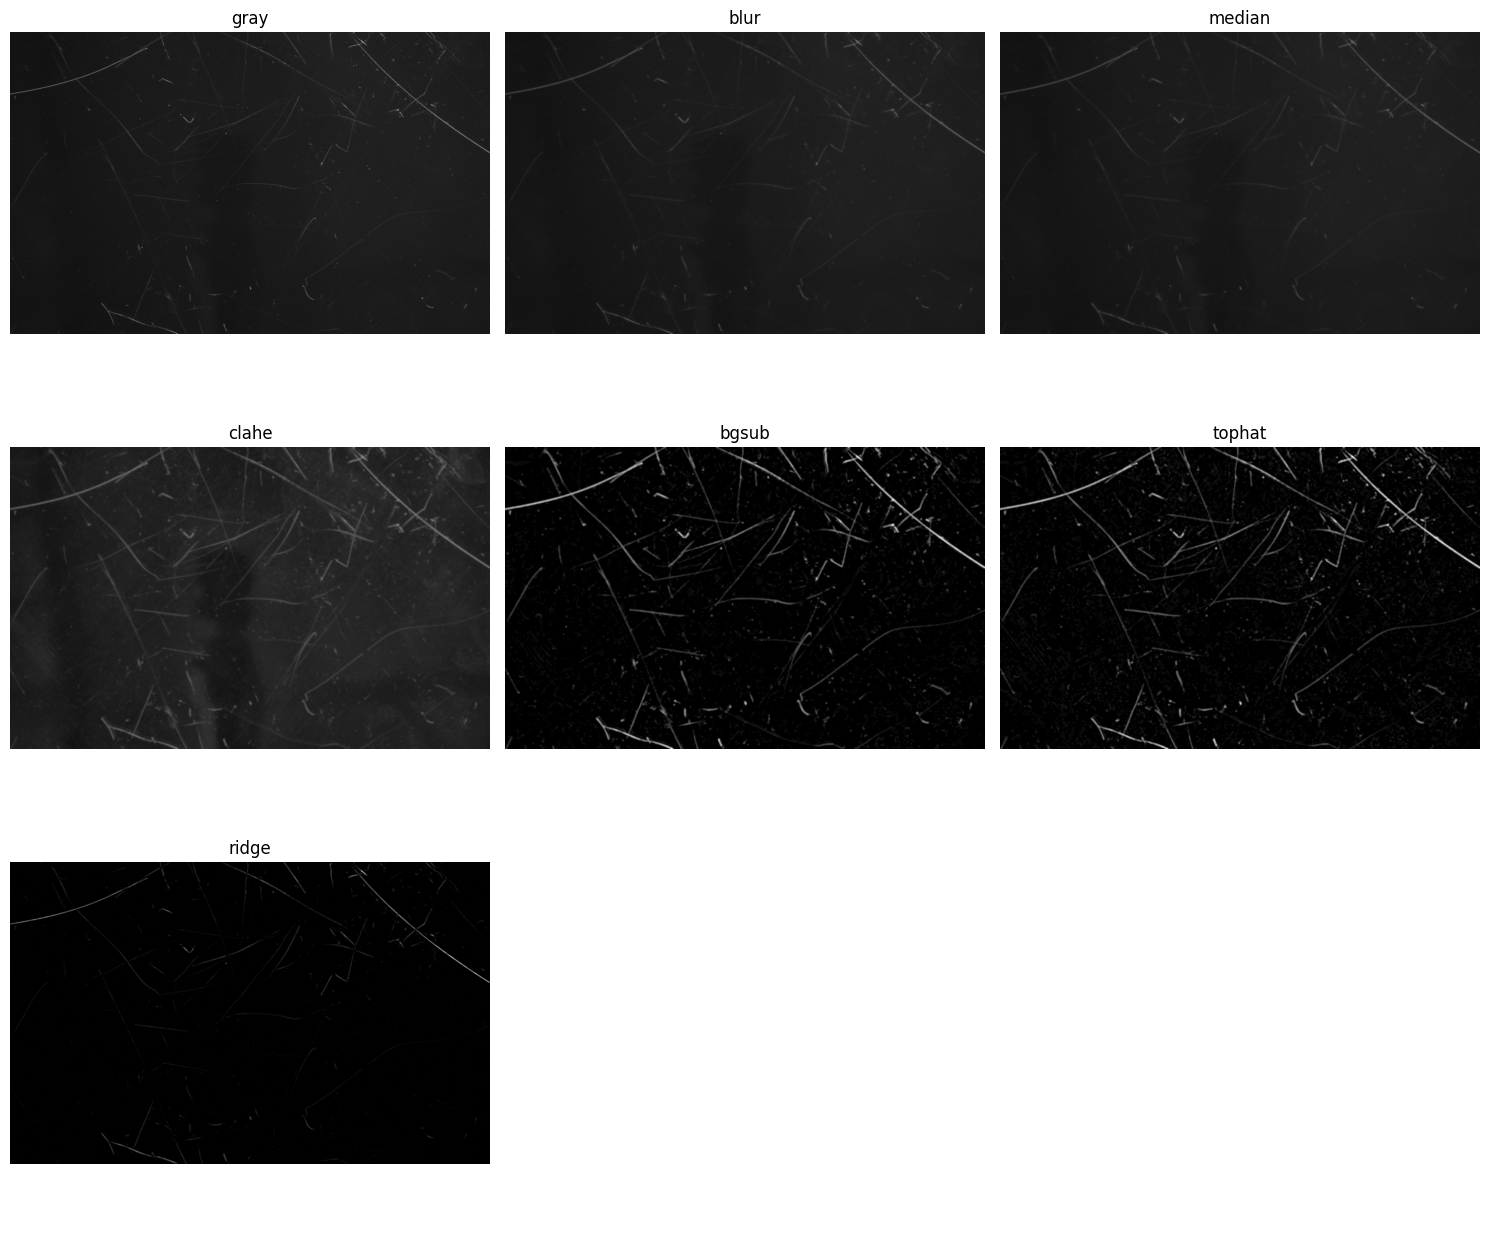

In [78]:
# Visualise every preprocessing stage. We auto-stretch the low-signal stages
# (bgsub, tophat, ridge) — their absolute values are small but the SHAPE of the
# response is what matters for thresholding. Without stretching they look black
# even when they contain perfectly usable scratch information.
stages = preprocess(sample, P)

STRETCH_STAGES = {'bgsub', 'tophat', 'ridge'}

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
for ax, (name, im) in zip(axes.ravel(), stages.items()):
    show(im, name, ax, stretch=(name in STRETCH_STAGES))
# Hide unused slots
for ax in axes.ravel()[len(stages):]:
    ax.set_axis_off()
plt.tight_layout(); plt.show()


## 4. Thresholding scratch candidates

Convert the (preprocessed) image into a binary candidate mask

$$
M(x,y) \;=\; 255\cdot \mathbf{1}\!\left[\,I(x,y) > T(x,y)\,\right].
$$

Eight flavours (the last three are the new additions for faint-scratch recovery):

**Fixed** — $T(x,y) = T_0$, global constant.

**Otsu** — picks $T^{\star}$ minimising within-class variance:
$\;T^{\star} = \arg\min_T\, w_0(T)\sigma_0^{2}(T) + w_1(T)\sigma_1^{2}(T)$.

**Adaptive (Gaussian)** — Gaussian-weighted local mean:
$T(x,y) = \sum_{i,j} w_{ij}\,I(x+i,y+j) - C$.

**Top-hat + Otsu** — Otsu on the polarity-aware top-hat.

**BgSub + Otsu** — Otsu on the polarity-aware background-subtracted residual.

**Ridge + Otsu (NEW)** — Otsu on the Frangi vesselness response. Combines the line-shape selectivity of Frangi with Otsu's data-driven cutoff. The default best detector for thin scratches.

**Ridge + Hysteresis (NEW)** — two cutoffs $T_{low} < T_{high}$ on the Frangi response: pixels above $T_{high}$ are *seeds*; pixels above $T_{low}$ join the mask **only if 8-connected to a seed**. Recovers the faint tails of a clear scratch and pieces together fragmented faint scratches without admitting isolated noise pixels.

**Hysteresis (CLAHE) (NEW)** — same idea but applied directly to the CLAHE-enhanced image. Useful as a baseline / sanity check against the ridge-based version.

*Polarity:* the inversion required by OpenCV's `THRESH_BINARY` is derived from `Params.bright_features` and applied automatically to the `fixed / otsu / adaptive` branches that operate on the raw CLAHE image. The `tophat / bgsub / ridge` branches always have bright-on-dark inputs by construction, so no inversion.

In [79]:
def _maybe_invert(img: np.ndarray, p: Params) -> np.ndarray:
    # Photometric negative I' = 255 - I. Required only when features are DARKER than
    # background, because THRESH_BINARY keeps pixels > T (not < T).
    return img if p.bright_features else cv.bitwise_not(img)


def _normalize_to_unit(img: np.ndarray) -> np.ndarray:
    """Rescale a float image so its peak is 1.0 (no-op if all zero).

    The Frangi response is in [0, 1] in theory but in practice peaks at ~0.02-0.5
    depending on contrast — making absolute hysteresis thresholds unreliable.
    Normalising to the per-image peak lets `hyst_low / hyst_high` mean
    'fraction of the strongest ridge in THIS image', which transfers between images.
    """
    m = float(img.max())
    if m <= 1e-12:
        return img.astype(np.float32)
    return (img.astype(np.float32) / m)


def thr_fixed(img, p: Params):
    src = _maybe_invert(img, p)
    _, m = cv.threshold(src, p.fixed_thresh, 255, cv.THRESH_BINARY)
    return m


def thr_otsu(img, p: Params):
    src = _maybe_invert(img, p)
    _, m = cv.threshold(src, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    return m


def thr_adaptive(img, p: Params):
    src = _maybe_invert(img, p)
    b = p.adaptive_block if p.adaptive_block % 2 == 1 else p.adaptive_block + 1
    return cv.adaptiveThreshold(src, 255,
                                cv.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv.THRESH_BINARY, b, p.adaptive_C)


def thr_tophat_otsu(stages):
    _, m = cv.threshold(stages['tophat'], 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    return m


def thr_bgsub_otsu(stages):
    _, m = cv.threshold(stages['bgsub'], 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    return m


def thr_ridge_otsu(stages):
    """Otsu on the Frangi response, with histogram-stretch first.

    Without stretching, the float response (often peaking at 0.02-0.05) would
    quantise to uint8 0-12 and Otsu's threshold lands at 0 → no foreground.
    cv.NORM_MINMAX maps [min, max] → [0, 255] before Otsu so the histogram
    actually fills the dynamic range.
    """
    r = stages['ridge']
    if r.max() <= 1e-9:
        return np.zeros(r.shape, dtype=np.uint8)
    r_u8 = cv.normalize(r, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
    _, m = cv.threshold(r_u8, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    return m


def thr_ridge_hysteresis(stages, low: float, high: float):
    """Hysteresis on the Frangi response, normalised to its peak.

    `low` and `high` are now interpreted as FRACTIONS OF PEAK RESPONSE in this image,
    e.g. low=0.05, high=0.20 means seeds are pixels above 20 % of the strongest ridge
    response and they grow into pixels above 5 % of it. Robust across images regardless
    of absolute Frangi magnitude.
    """
    r = stages['ridge']
    if r.max() <= 1e-9:
        return np.zeros(r.shape, dtype=np.uint8)
    r_norm = _normalize_to_unit(r)
    return (_hysteresis(r_norm, low, high).astype(np.uint8) * 255)


def thr_hysteresis(stages, low: float, high: float, p: Params):
    """Hysteresis on the CLAHE-enhanced uint8 image, normalised to [0, 1] first.

    Note: CLAHE produces a near-uniformly-bright output, so the natural cutoffs are
    HIGH (e.g. low=0.6, high=0.85) — the defaults are tuned for the Frangi branch.
    """
    src = _maybe_invert(stages['clahe'], p).astype(np.float32) / 255.0
    return (_hysteresis(src, low, high).astype(np.uint8) * 255)


def candidate_mask(stages: dict, p: Params) -> np.ndarray:
    """Dispatch to the threshold method named in p.threshold_method."""
    m = p.threshold_method
    if m == 'fixed':            return thr_fixed(stages['clahe'], p)
    if m == 'otsu':             return thr_otsu(stages['clahe'], p)
    if m == 'adaptive':         return thr_adaptive(stages['clahe'], p)
    if m == 'tophat_otsu':      return thr_tophat_otsu(stages)
    if m == 'bgsub_otsu':       return thr_bgsub_otsu(stages)
    if m == 'ridge_otsu':       return thr_ridge_otsu(stages)
    if m == 'ridge_hysteresis': return thr_ridge_hysteresis(stages, p.hyst_low, p.hyst_high)
    if m == 'hysteresis':       return thr_hysteresis(stages, p.hyst_low, p.hyst_high, p)
    raise ValueError(f'unknown threshold_method: {m}')


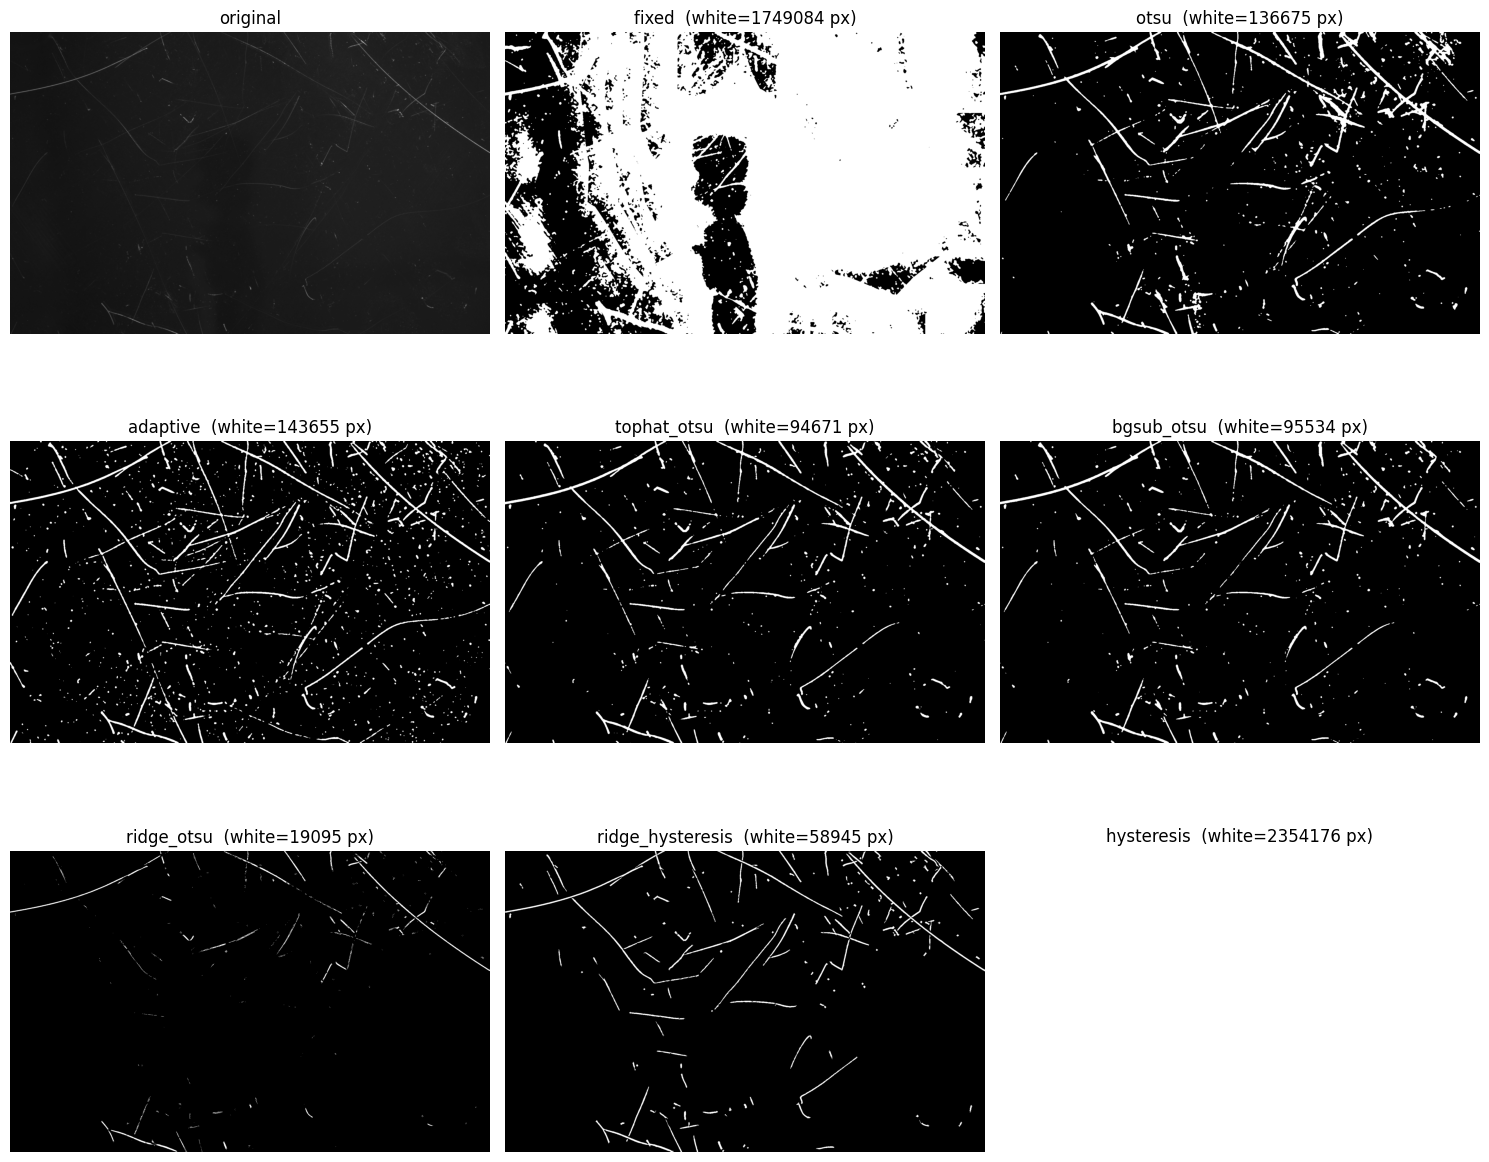

In [80]:
# Side-by-side comparison of every method on the sample image — visual tool to pick
# the one that best isolates faint + clear scratches while suppressing dust.
methods = {
    'fixed':            thr_fixed(stages['clahe'], P),
    'otsu':             thr_otsu(stages['clahe'], P),
    'adaptive':         thr_adaptive(stages['clahe'], P),
    'tophat_otsu':      thr_tophat_otsu(stages),
    'bgsub_otsu':       thr_bgsub_otsu(stages),
    'ridge_otsu':       thr_ridge_otsu(stages),
    'ridge_hysteresis': thr_ridge_hysteresis(stages, P.hyst_low, P.hyst_high),
    'hysteresis':       thr_hysteresis(stages, P.hyst_low, P.hyst_high, P),
}

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
axes = axes.ravel()
show(sample, 'original', axes[0])
for ax, (name, m) in zip(axes[1:], methods.items()):
    show(m, f'{name}  (white={int((m>0).sum())} px)', ax)
plt.tight_layout(); plt.show()

## 5. Dust and noise filtering

The candidate mask still contains specks (dust, sensor noise) and tiny artefacts. Two clean-up stages:

### 5.1 Morphology — clean the *pixels*

$$
(I \ominus S)(x) = \min_{s\in S} I(x+s), \qquad (I \oplus S)(x) = \max_{s\in S} I(x+s)
$$

$$
\gamma_S(I) = (I \ominus S)\oplus S \;\;\text{(opening, removes bright structures smaller than }S\text{)}
$$

$$
\phi_S(I) = (I \oplus S)\ominus S \;\;\text{(closing, fills dark gaps smaller than }S\text{)}
$$

On a binary mask, opening with a small $S$ kills isolated white speckles — but it also erases 1-px wide faint scratches. With faint-scratch recovery enabled we **skip opening** (`open_ksize=0`) and rely on the component filter to remove blobs.

### 5.2 Connected-component filter — clean the *objects*

For each 8-connected component $C$ (bbox $w\times h$, area $A$):

$$
\begin{aligned}
\text{length}      \;& L    = \max(w, h) \\
\text{aspect}      \;& \mathrm{AR} = \max(w, h) / \max(\min(w, h),\,1) \\
\text{elongation}  \;& e    = a_{\text{major}} / a_{\text{minor}} \quad \text{(fitted ellipse)} \\
\text{solidity}    \;& s    = A / |\mathrm{ConvexHull}(C)|
\end{aligned}
$$

Kept iff
$$
\text{min\_area} \le A \le \text{max\_area},\;
L \ge \text{min\_length},\;
\mathrm{AR} \ge \text{min\_aspect},\;
e \ge \text{min\_elong},\;
s \le \text{max\_solidity}.
$$

Defaults are loose (small `min_area`, modest `min_aspect_ratio`) so faint short scratches survive. Tighten if your debug overlays show too many dust grains slipping through.

In [81]:
_COMPONENT_COLUMNS = ['id', 'x', 'y', 'w', 'h', 'area',
                      'length', 'aspect', 'elongation', 'solidity',
                      'skel_len', 'width', 'slenderness', 'kept']


def morphology_clean(mask: np.ndarray, p: Params) -> np.ndarray:
    """Opening (γ_S) → Closing (φ_S) on the binary mask.

    Order: open first (kill speckles), then close (bridge intra-scratch gaps).
    If open_ksize == 0 the opening is skipped — recommended when chasing faint scratches.
    """
    out = mask
    if p.open_ksize and p.open_ksize >= 1:
        k = cv.getStructuringElement(cv.MORPH_RECT, (p.open_ksize, p.open_ksize))
        out = cv.morphologyEx(out, cv.MORPH_OPEN, k)
    if p.close_ksize and p.close_ksize >= 1:
        k = cv.getStructuringElement(cv.MORPH_RECT, (p.close_ksize, p.close_ksize))
        out = cv.morphologyEx(out, cv.MORPH_CLOSE, k)
    return out


def _ellipse_elongation(contour) -> float:
    """Major/minor axis ratio of the ellipse fitted to the contour.

    Need ≥5 contour points for cv.fitEllipse; return +inf otherwise (tiny stubs are
    killed by the area/length gate anyway).
    """
    if len(contour) < 5:
        return float('inf')
    (_, (ax_a, ax_b), _) = cv.fitEllipse(contour)
    short, long = sorted((ax_a, ax_b))
    return float('inf') if short < 1e-3 else long / short


def _solidity(contour, area: float) -> float:
    """s = |C| / |ConvexHull(C)|. Convex blob → s ≈ 1; long thin curve → s ≪ 1."""
    hull = cv.convexHull(contour)
    hull_area = cv.contourArea(hull)
    return 1.0 if hull_area <= 0 else area / hull_area


def _skeleton_metrics(comp_bool: np.ndarray, area: float) -> tuple[int, float, float]:
    """Skeleton-derived shape metrics for one component (boolean mask).

    Thin the component to a 1-px-wide centreline and measure:
      - skel_len    = number of skeleton pixels ≈ geodesic length of the centreline.
      - width       = area / skel_len ≈ mean stroke width (area spread over the centreline).
      - slenderness = skel_len / width = skel_len**2 / area
                    ≈ how many stroke-widths long the centreline is.

    Why slenderness and not width alone: on chunky Otsu masks a real scratch can be
    several px wide, so width does NOT separate it from a dust grain (both are ~4-17 px
    here). What separates them is that a scratch's centreline is LONG relative to that
    width while a grain's skeleton collapses to a stub. slenderness captures exactly
    that, independent of orientation, curvature and absolute size — and unlike the
    fitted-ellipse elongation it has no degenerate <5-point regime to go noisy in.
    """
    skel_len = int(_skeletonize(comp_bool).sum())
    width    = area / max(skel_len, 1)
    slender  = (skel_len * skel_len) / max(area, 1)
    return skel_len, width, slender


def filter_components(mask: np.ndarray, p: Params) -> tuple[np.ndarray, pd.DataFrame]:
    """8-connected components + per-component geometric gate.

    aspect and elongation are two different proxies for the same property (how
    line-like a component is). When scratches cross or are bordered by dust the
    bbox gets wider and aspect collapses, but the fitted ellipse still has a
    large major/minor ratio — and vice versa for short, straight, isolated
    scratches where the ellipse fit is noisy but the bbox aspect is clean. So
    we keep a component if EITHER one passes its threshold, not both.

    On top of that OR we AND a skeleton slenderness floor (skel_len**2 / area).
    Both aspect and elongation are bounding-box / ellipse proxies that a compact
    dust grain can fake — a noisy ellipse fit on a near-circular blob reports a
    spurious major/minor ratio above min_elongation and the grain sneaks through.
    The skeleton sees the actual centreline: a grain's collapses to a short stub
    (slenderness < ~1) while a real scratch's stays long relative to its width
    (median ~5 here). So slenderness is the gate that finally drops the dust the
    OR lets in, without trusting either bbox or ellipse.

    The DataFrame ALWAYS has the columns in _COMPONENT_COLUMNS, even when no
    component is found (would otherwise be a column-less DataFrame and df.kept
    would raise AttributeError).
    """
    num, labels, stats, _ = cv.connectedComponentsWithStats(mask, connectivity=8)
    kept = np.zeros_like(mask)
    rows = []
    for i in range(1, num):  # 0 is background
        x, y, w, h, area = stats[i]
        length    = max(w, h)
        thickness = max(min(w, h), 1)
        aspect    = length / thickness

        comp_bool = (labels == i)
        comp = comp_bool.astype(np.uint8) * 255
        contours, _ = cv.findContours(comp, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
        contour = max(contours, key=cv.contourArea) if contours else None
        elong    = _ellipse_elongation(contour) if contour is not None else 0.0
        solidity = _solidity(contour, area)     if contour is not None else 1.0
        skel_len, width, slenderness = _skeleton_metrics(comp_bool, area)

        shape_ok = (aspect >= p.min_aspect_ratio) or (elong >= p.min_elongation)
        keep = (
            p.min_area <= area <= p.max_area and
            length      >= p.min_length and
            shape_ok and
            solidity    <= p.max_solidity and
            slenderness >= p.min_slenderness   # skeleton dust gate (drops compact grains)
        )
        rows.append(dict(id=i, x=x, y=y, w=w, h=h, area=int(area),
                         length=length, aspect=round(aspect, 2),
                         elongation=round(elong, 2),
                         solidity=round(solidity, 3),
                         skel_len=skel_len, width=round(width, 2),
                         slenderness=round(slenderness, 2), kept=bool(keep)))
        if keep:
            kept[labels == i] = 255
    df = pd.DataFrame(rows, columns=_COMPONENT_COLUMNS)
    df['kept'] = df['kept'].astype(bool)   # bool dtype even on empty frame
    return kept, df

In [82]:
# Inspect every component with its metrics — drop kept=False rows into a scatter plot
# (aspect vs solidity, for example) when tuning to see the decision boundary.
candidate = candidate_mask(stages, P)
cleaned   = morphology_clean(candidate, P)
final, df = filter_components(cleaned, P)

print(f'candidate pixels: {int((candidate > 0).sum())}'
      f'   cleaned pixels: {int((cleaned > 0).sum())}'
      f'   final pixels: {int((final > 0).sum())}')
print(f'components: {len(df)}   kept: {int(df["kept"].sum()) if len(df) else 0}')

if len(df) == 0:
    print('No connected components survived the candidate/morphology stages — '
          'the threshold is probably too aggressive. Try lowering hyst_low / hyst_high '
          'or switching threshold_method to bgsub_otsu.')
df.head(20)


candidate pixels: 58945   cleaned pixels: 55408   final pixels: 48365
components: 224   kept: 104


,id,x,y,w,h,area,length,aspect,elongation,solidity,skel_len,width,slenderness,kept
0,1,540,0,84,62,728,84,1.35,1.19,0.274,124,5.87,21.12,False
1,2,737,0,31,83,415,83,2.68,9.05,0.736,81,5.12,15.81,True
2,3,855,0,505,268,2958,505,1.88,27.84,0.479,502,5.89,85.19,True
3,4,956,0,6,40,183,40,6.67,8.10,1.025,38,4.82,7.89,True
4,5,1104,0,92,129,859,129,1.40,36.49,0.895,128,6.71,19.07,True
5,6,1384,0,8,5,37,8,1.60,1.84,1.423,6,6.17,0.97,False
6,7,1489,0,27,42,267,42,1.56,3.22,0.641,47,5.68,8.27,True
7,8,1676,0,70,64,508,70,1.09,9.07,0.641,74,6.86,10.78,True
8,9,1695,0,22,25,179,25,1.14,5.63,1.065,22,8.14,2.70,True
9,10,1738,0,6,6,29,6,1.00,1.28,1.349,4,7.25,0.55,False


## 6. Scratch mask generation

`build_mask` chains §3–§5 and returns every intermediate (used by the debug overlay). `save_mask` guarantees the output PNG is strictly $\{0, 255\}$-valued `uint8` with the **same filename and shape** as the source — the contract the future U-Net dataset will rely on.

In [83]:
def build_mask(img: np.ndarray, p: Params) -> dict:
    stages    = preprocess(img, p)
    candidate = candidate_mask(stages, p)
    cleaned   = morphology_clean(candidate, p)
    final, df = filter_components(cleaned, p)
    return dict(stages=stages, candidate=candidate, cleaned=cleaned,
                final=final, components=df)

def save_mask(mask: np.ndarray, src_path: Path, out_dir: Path) -> Path:
    """Same filename and same HxW as the source image. Always PNG-encoded uint8 {0,255}."""
    out_path = out_dir / src_path.name
    binarized = np.where(mask > 0, 255, 0).astype(np.uint8)
    cv.imwrite(str(out_path), binarized)
    return out_path

## 7. Debug visualization

Side-by-side panels for fast visual QA, plus a translucent overlay

$$
I_{\text{ovl}} = (1-\alpha)\,I_{\text{rgb}} + \alpha\,C_{\text{mask}}
$$

to spot scratches the mask missed or dust it kept.

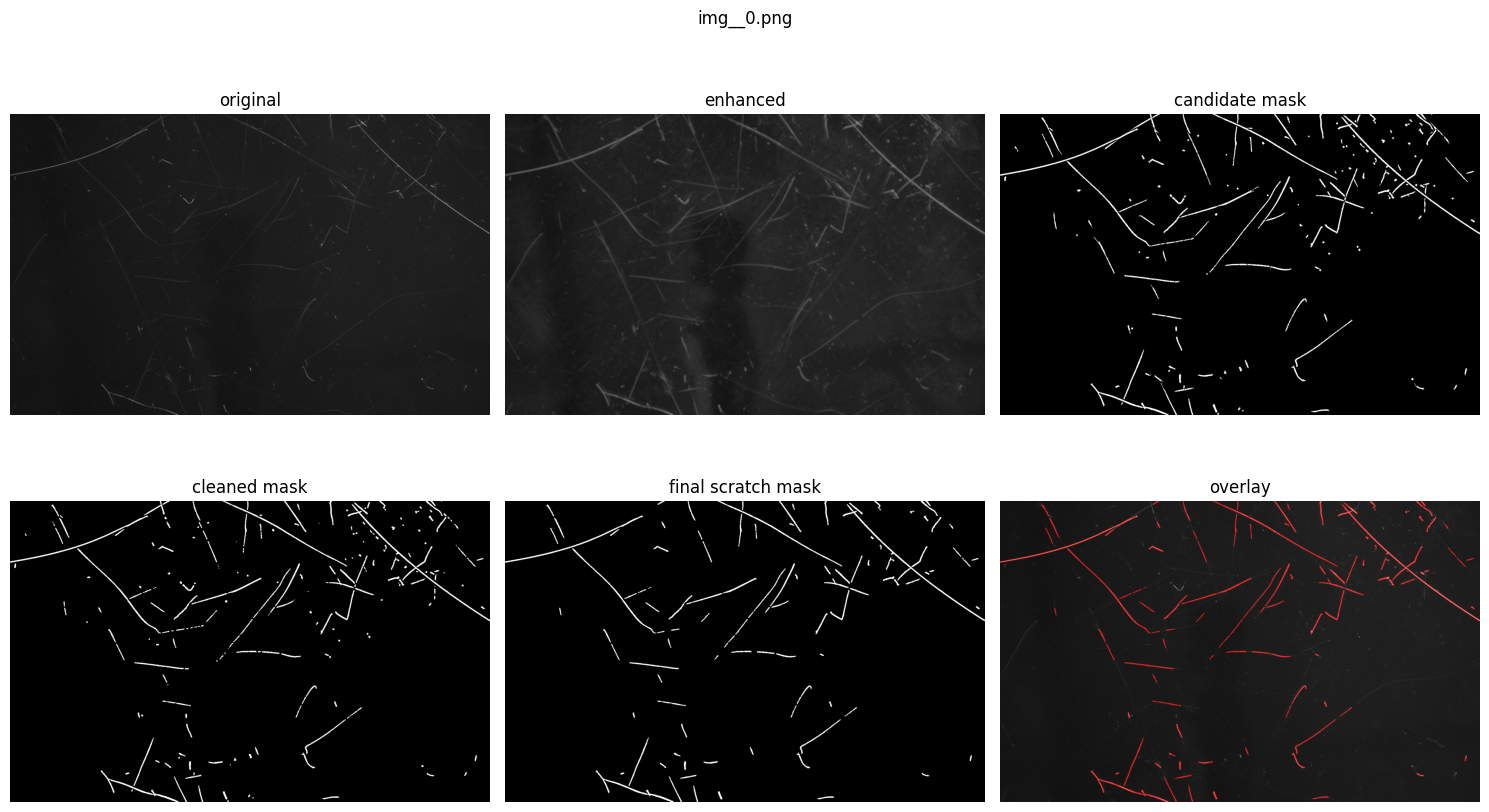

In [84]:
def overlay_mask(gray: np.ndarray, mask: np.ndarray, color=(0, 0, 255), alpha: float = 0.5) -> np.ndarray:
    """Alpha-blend the mask on top of the grayscale image as a colored overlay.

    I_ovl = (1 - α)·I + α·C_mask, with C_mask = color at mask>0, 0 elsewhere.
    Color is BGR (OpenCV convention); (0,0,255) = pure red.
    """
    bgr = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)
    paint = np.zeros_like(bgr); paint[mask > 0] = color
    return cv.addWeighted(bgr, 1.0, paint, alpha, 0)

def show_debug(img: np.ndarray, res: dict, title: str = ''):
    ov = overlay_mask(img, res['final'], alpha=0.7)
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    show(img,                'original',         axes[0, 0])
    show(res['stages']['clahe'], 'enhanced',     axes[0, 1])
    show(res['candidate'],   'candidate mask',   axes[0, 2])
    show(res['cleaned'],     'cleaned mask',     axes[1, 0])
    show(res['final'],       'final scratch mask', axes[1, 1])
    axes[1, 2].imshow(cv.cvtColor(ov, cv.COLOR_BGR2RGB)); axes[1, 2].set_title('overlay'); axes[1, 2].set_axis_off()
    fig.suptitle(title); plt.tight_layout(); plt.show()

res = build_mask(sample, P)
show_debug(sample, res, sample_path.name)

## 9. Batch processing

For every image in `RAW_DIR`:

1. load → preprocess → threshold → clean → filter
2. save the final mask to `MASKS_DIR/<same_name>`
3. save a side-by-side debug strip to `DEBUG_DIR/<same_name>`

In [85]:
def save_debug_overlay(img: np.ndarray, res: dict, src_path: Path, out_dir: Path) -> Path:
    """4-panel horizontal strip [original | candidate | final | overlay]."""
    ov = overlay_mask(img, res['final'])
    cand_bgr  = cv.cvtColor(res['candidate'], cv.COLOR_GRAY2BGR)
    final_bgr = cv.cvtColor(res['final'],     cv.COLOR_GRAY2BGR)
    img_bgr   = cv.cvtColor(img,              cv.COLOR_GRAY2BGR)
    strip = np.concatenate([img_bgr, cand_bgr, final_bgr, ov], axis=1)
    out_path = out_dir / src_path.name
    cv.imwrite(str(out_path), strip)
    return out_path

def process_batch(raw_dir: Path, mask_dir: Path, debug_dir: Path,
                  p: Params, save_debug: bool = True) -> pd.DataFrame:
    rows = []
    paths = list_images(raw_dir)
    for i, src in enumerate(paths, 1):
        img = load_gray(src)
        res = build_mask(img, p)
        m_path = save_mask(res['final'], src, mask_dir)
        d_path = save_debug_overlay(img, res, src, debug_dir) if save_debug else None
        rows.append(dict(
            name=src.name,
            shape=f'{img.shape[1]}x{img.shape[0]}',
            scratch_px=int((res['final'] > 0).sum()),
            components_total=len(res['components']),
            components_kept=int(res['components'].kept.sum()),
            mask=str(m_path),
            debug=str(d_path) if d_path else '',
        ))
        if i % 10 == 0 or i == len(paths):
            print(f'  {i}/{len(paths)}')
    return pd.DataFrame(rows)

# Run on the whole folder. Comment out if you are still tuning on one image.
summary = process_batch(RAW_DIR, MASKS_DIR, DEBUG_DIR, P)
summary

  1/1


,name,shape,scratch_px,components_total,components_kept,mask,debug
0,img__0.png,1936x1216,48365,224,104,data_1/generated_masks/img__0.png,data_1/debug_outputs/img__0.png


## 10. Dataset preparation for a future U-Net

Two non-obvious points:

1. **Resize masks with `INTER_NEAREST`.** Bilinear would produce intermediate values (e.g. 128) at scratch edges → no longer a valid binary label.
2. **Split by source image, not by tile.** Tiles from one photo are correlated; if some end up in *train* and others in *val*, the network memorises the photo and validation metrics overstate generalisation:

$$
\mathcal{S} = \mathcal{S}_{tr} \sqcup \mathcal{S}_{val} \sqcup \mathcal{S}_{te}
\;\Longrightarrow\;
\mathcal{T}_{tr} = \bigcup_{s\in\mathcal{S}_{tr}} \mathcal{T}_s, \text{ etc.}
$$

Tile rejection: drop a tile if scratch-pixel fraction $\rho = \tfrac{1}{HW}\sum_{x,y}\mathbf{1}[M(x,y)>0]$ is below `MIN_POS_FRAC`.

In [86]:
DATASET_DIR = ROOT / 'dataset'
for split in ('train', 'val', 'test'):
    (DATASET_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / split / 'masks' ).mkdir(parents=True, exist_ok=True)

TILE_SIZE   = 512
TILE_STRIDE = 512
MIN_POS_FRAC = 1e-4

def resize_pair(img, mask, size):
    """Image: area-resampling (anti-aliased downscale). Mask: nearest-neighbour to keep labels binary."""
    img_r  = cv.resize(img,  size, interpolation=cv.INTER_AREA)
    mask_r = cv.resize(mask, size, interpolation=cv.INTER_NEAREST)
    return img_r, mask_r

def tile_pair(img, mask, tile: int = TILE_SIZE, stride: int = TILE_STRIDE):
    H, W = img.shape[:2]
    for y in range(0, H - tile + 1, stride):
        for x in range(0, W - tile + 1, stride):
            yield img[y:y+tile, x:x+tile], mask[y:y+tile, x:x+tile], (y, x)

def is_non_empty(mask_tile, min_frac: float = MIN_POS_FRAC) -> bool:
    return (mask_tile > 0).mean() >= min_frac

def check_pairs(raw_dir: Path, mask_dir: Path) -> pd.DataFrame:
    rows = []
    for src in list_images(raw_dir):
        m = mask_dir / src.name
        rows.append(dict(name=src.name, mask_exists=m.exists()))
    return pd.DataFrame(rows)

def split_by_image(names, val_frac: float = 0.15, test_frac: float = 0.15, seed: int = 0):
    """Disjoint train/val/test split over SOURCE images."""
    rng = np.random.default_rng(seed)
    names = np.array(sorted(names)); rng.shuffle(names)
    n_test = int(round(len(names) * test_frac))
    n_val  = int(round(len(names) * val_frac))
    test, val, train = names[:n_test], names[n_test:n_test+n_val], names[n_test+n_val:]
    return dict(train=list(train), val=list(val), test=list(test))

# Skeleton — fill in once masks look good:
# pairs = check_pairs(RAW_DIR, MASKS_DIR); print(pairs)
# splits = split_by_image([p.name for p in list_images(RAW_DIR)])
# for split, names in splits.items():
#     for n in names:
#         img  = load_gray(RAW_DIR / n)
#         mask = load_gray(MASKS_DIR / n)
#         for k, (it, mt, _) in enumerate(tile_pair(img, mask)):
#             if not is_non_empty(mt):
#                 continue
#             stem = Path(n).stem
#             cv.imwrite(str(DATASET_DIR / split / 'images' / f'{stem}_{k:04d}.png'), it)
#             cv.imwrite(str(DATASET_DIR / split / 'masks'  / f'{stem}_{k:04d}.png'), mt)

## 11. Future PyTorch ingredients

Placeholders only — do not train here. Two loss components designed for the **heavy class imbalance** of scratch segmentation (foreground is < 1 % of pixels):

**Binary Cross-Entropy** (per-pixel, with logits $\hat z$ and target $y\in\{0,1\}$):

$$
\mathcal{L}_{\mathrm{BCE}}(\hat z, y) = -\frac{1}{N}\sum_{i=1}^{N}\Bigl[y_i\,\log\sigma(\hat z_i) + (1-y_i)\,\log\bigl(1-\sigma(\hat z_i)\bigr)\Bigr]
$$

**Soft Dice loss** (overlap-based, invariant to class frequency):

$$
\mathcal{L}_{\mathrm{Dice}}(\hat p, y) = 1 - \frac{2\sum_i \hat p_i\,y_i + \varepsilon}{\sum_i \hat p_i + \sum_i y_i + \varepsilon},\quad \hat p_i = \sigma(\hat z_i)
$$

Combined: $\mathcal{L} = \mathcal{L}_{\mathrm{BCE}} + \mathcal{L}_{\mathrm{Dice}}$.

In [87]:
PYTORCH_PLAN = r'''
from torch.utils.data import Dataset, DataLoader
import torch, torch.nn.functional as F

class ScratchDataset(Dataset):
    """Yields (image_tensor[1,H,W], mask_tensor[1,H,W]) pairs.

    - image:  float32 in [0, 1]   (normalisation = divide by 255)
    - mask:   float32 in {0, 1}   (binary label for BCE / Dice)
    """
    def __init__(self, img_dir, mask_dir, transform=None):
        self.imgs  = sorted(Path(img_dir).iterdir())
        self.masks = [Path(mask_dir) / p.name for p in self.imgs]
        self.transform = transform
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        img  = cv.imread(str(self.imgs[i]),  cv.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
        mask = cv.imread(str(self.masks[i]), cv.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)
        if self.transform:
            img, mask = self.transform(img, mask)
        return torch.from_numpy(img)[None], torch.from_numpy(mask)[None]

def bce_dice_loss(pred_logits, target, eps=1e-6):
    """L = BCE(σ(ẑ), y) + Dice(σ(ẑ), y). Uses _with_logits for numerical stability."""
    bce = F.binary_cross_entropy_with_logits(pred_logits, target)
    p   = torch.sigmoid(pred_logits)
    inter = (p * target).sum(dim=(2, 3))
    denom = p.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    dice  = 1 - (2 * inter + eps) / (denom + eps)
    return bce + dice.mean()
'''
print(PYTORCH_PLAN)


from torch.utils.data import Dataset, DataLoader
import torch, torch.nn.functional as F

class ScratchDataset(Dataset):
    """Yields (image_tensor[1,H,W], mask_tensor[1,H,W]) pairs.

    - image:  float32 in [0, 1]   (normalisation = divide by 255)
    - mask:   float32 in {0, 1}   (binary label for BCE / Dice)
    """
    def __init__(self, img_dir, mask_dir, transform=None):
        self.imgs  = sorted(Path(img_dir).iterdir())
        self.masks = [Path(mask_dir) / p.name for p in self.imgs]
        self.transform = transform
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        img  = cv.imread(str(self.imgs[i]),  cv.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
        mask = cv.imread(str(self.masks[i]), cv.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)
        if self.transform:
            img, mask = self.transform(img, mask)
        return torch.from_numpy(img)[None], torch.from_numpy(mask)[None]

def bce_dice_loss(pred_logits, t

## 12. Mask QA & batch over the A / B / C train glasses + val

The dataset is exported per glass: `dataset/train/images/{A,B,C}-<ts>/<label>/img__*.png`
and `dataset/val/images/validation-<ts>/validation/img__*.png`.

Two cells:

1. **QA** — randomly sample 2 images from each of glasses A, B, C (6 total) and put the
   **cleaned mask** (pre component-filter) next to the **final scratch overlay**, so you
   can eyeball whether the §5.2 geometric + skeleton gate is keeping real scratches and
   dropping dust on *each* glass before committing to a full run. Change `seed` to resample.
2. **Batch** — apply `build_mask` to every train + val image and save each binary mask to
   the mirrored path under `…/masks/`, ready for the §10 tiling/splitting step.

train: {'A': 128, 'B': 127, 'C': 149}
val:   {'validation': 152}
using threshold_method='ridge_hysteresis'  hyst=0.03/0.12


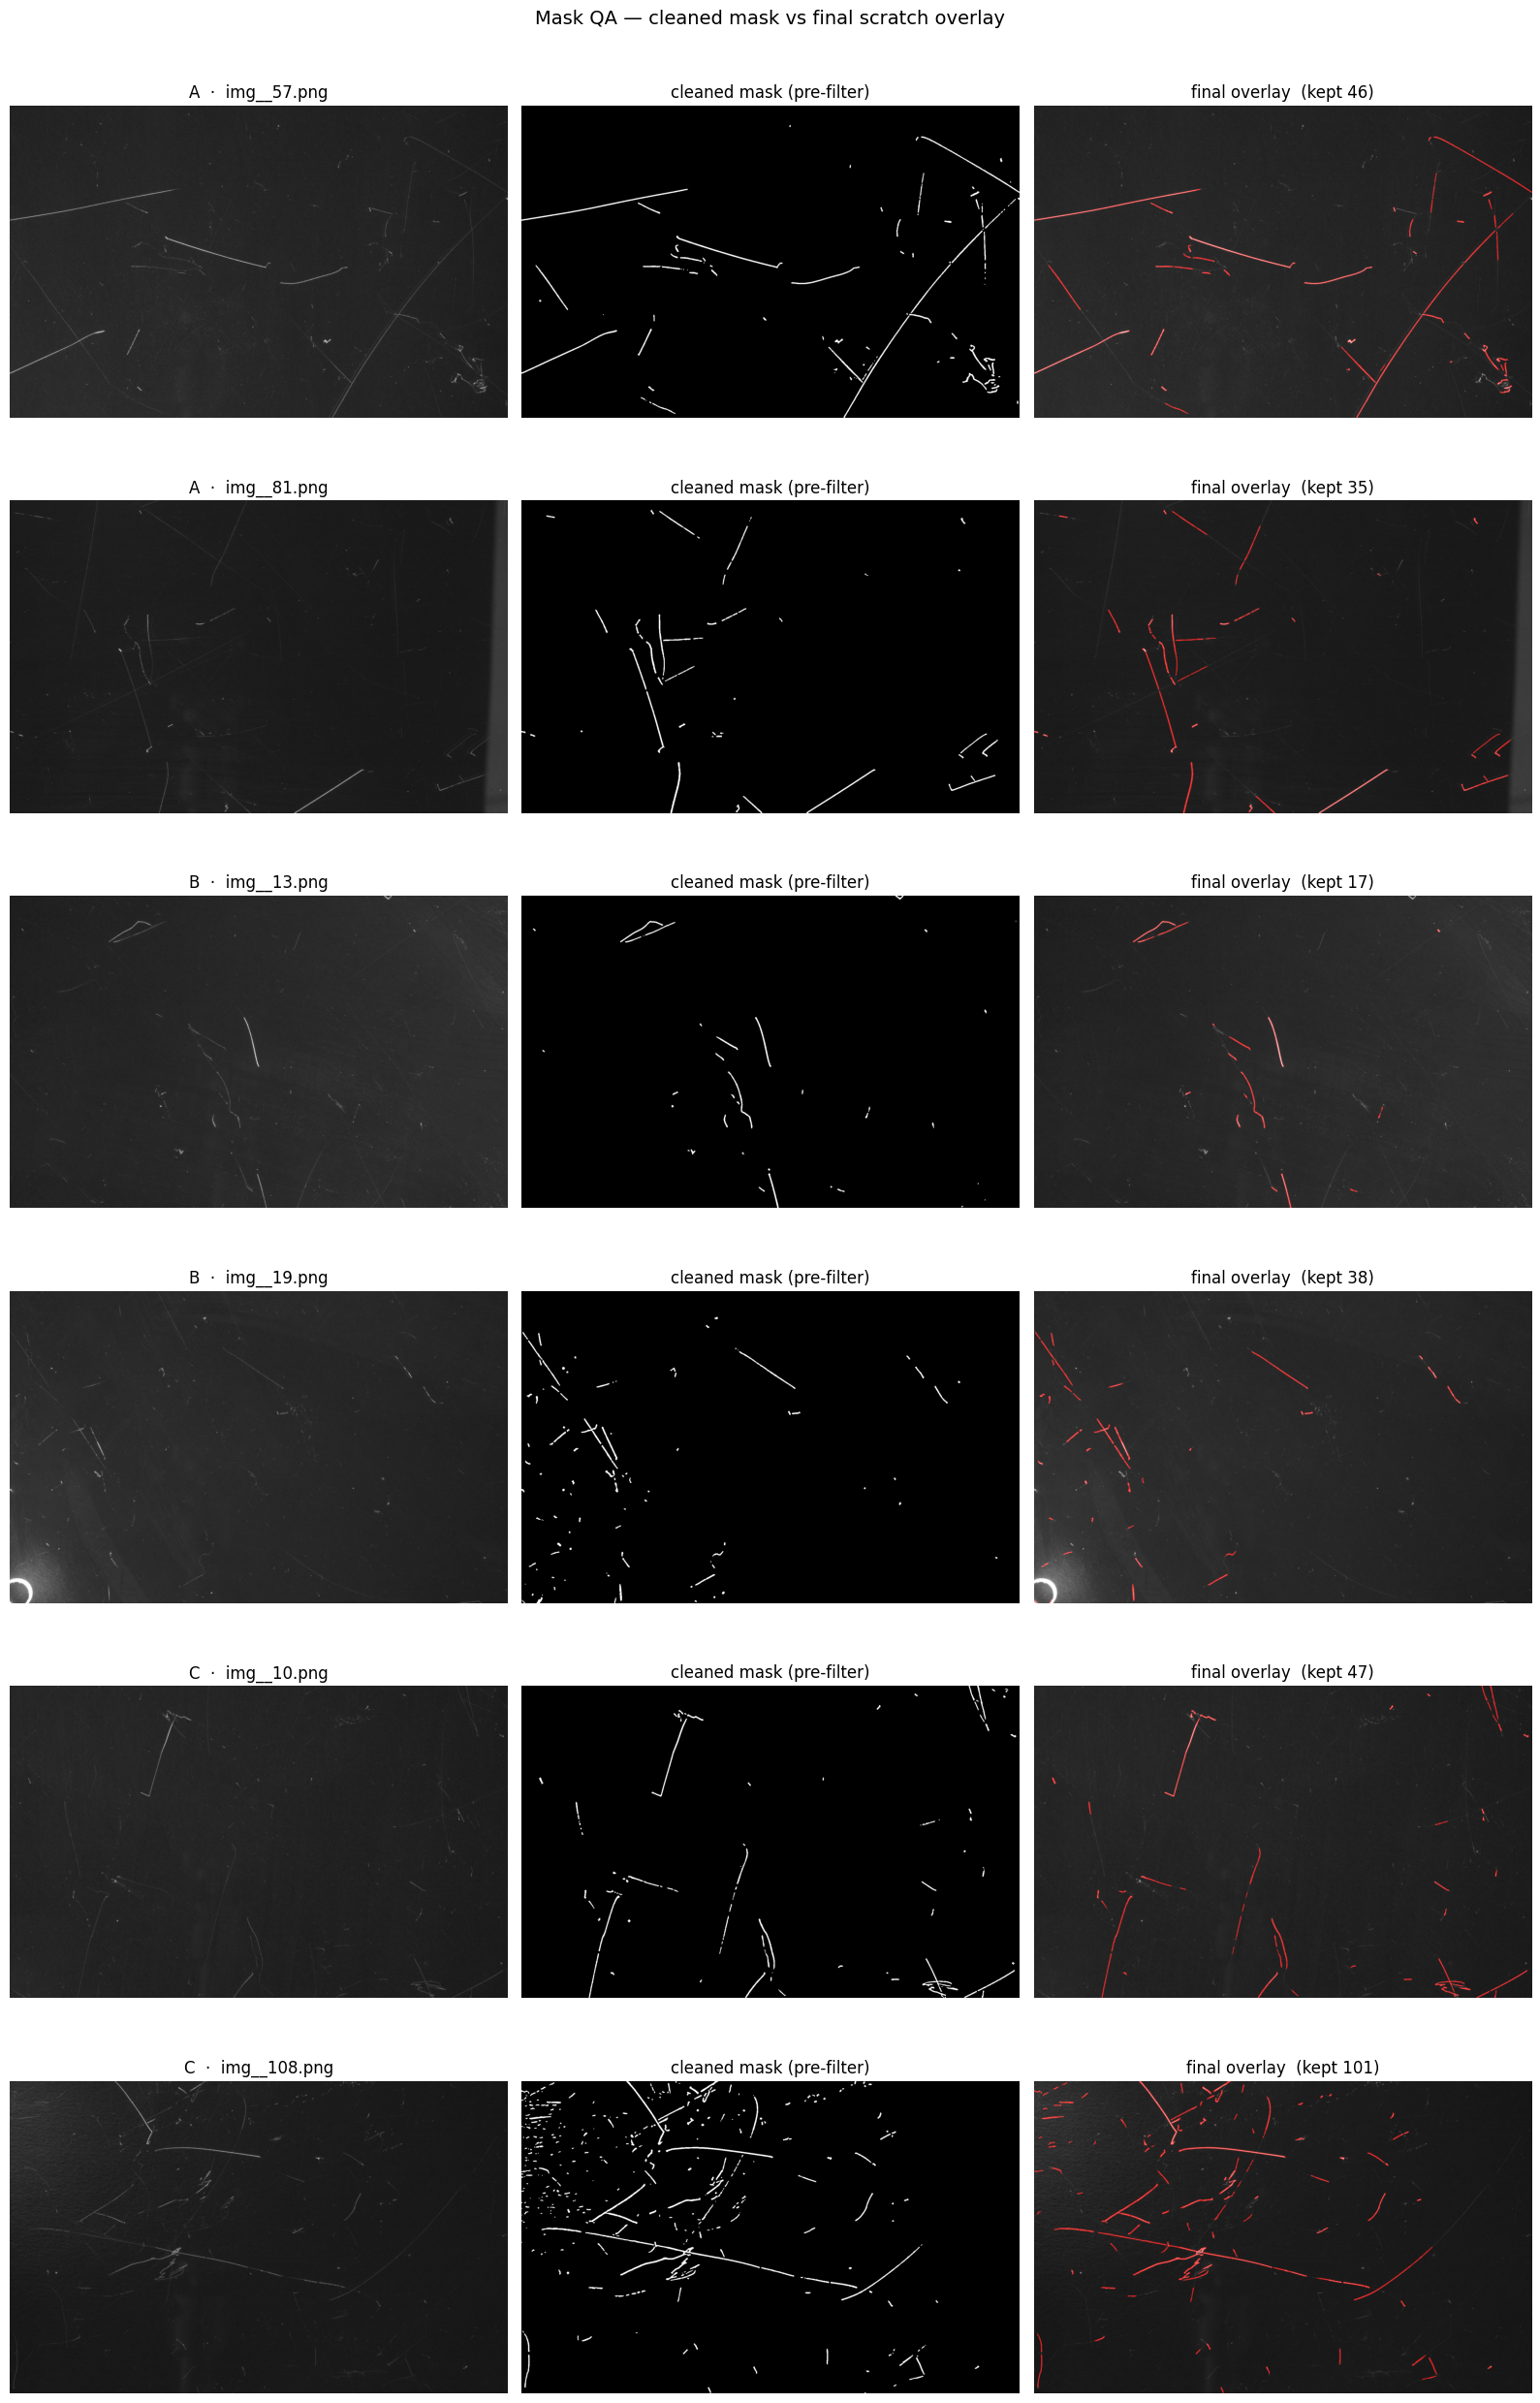

In [ ]:
def list_glass_images(split_images_dir: Path) -> dict:
    """Group every PNG under a split's images/ tree by glass label.

    The Drive export nests each glass as '<label>-<timestamp>-.../<label>/img__*.png'
    (train → A / B / C, val → 'validation'), so the label is the first path component
    with its timestamp suffix stripped.
    """
    groups = {}
    for p in sorted(split_images_dir.rglob('*.png')):
        label = p.relative_to(split_images_dir).parts[0].split('-')[0]
        groups.setdefault(label, []).append(p)
    return groups

train_groups = list_glass_images(DATASET_DIR / 'train' / 'images')
val_groups   = list_glass_images(DATASET_DIR / 'val'   / 'images')
print('train:', {k: len(v) for k, v in train_groups.items()})
print('val:  ', {k: len(v) for k, v in val_groups.items()})


def show_mask_qa(groups, glasses=('A', 'B', 'C'), per_glass=2, p=None, seed=0):
    """Random-sample `per_glass` images from each glass and show cleaned mask vs final overlay.

    One row per sampled image: [ original | cleaned mask | final overlay ]. The cleaned
    mask (§5.1, after morphology but BEFORE the §5.2 component filter) sits next to the
    post-filter overlay, so the middle-vs-right gap shows exactly what the geometric +
    skeleton gate removed as dust. The overlay title reports how many components survived.
    """
    p = P if p is None else p   # read the CURRENT global P, not a stale def-time copy
    print(f'using threshold_method={p.threshold_method!r}  hyst={p.hyst_low}/{p.hyst_high}')
    rng = np.random.default_rng(seed)
    picks = []
    for g in glasses:
        paths = groups.get(g, [])
        if not paths:
            print(f'glass {g!r}: no images found, skipping')
            continue
        idx = rng.choice(len(paths), size=min(per_glass, len(paths)), replace=False)
        picks += [(g, paths[i]) for i in sorted(idx)]

    n = len(picks)
    fig, axes = plt.subplots(n, 3, figsize=(16, 4.2 * n))
    axes = np.atleast_2d(axes)
    for row, (g, path) in enumerate(picks):
        img = load_gray(path)
        res = build_mask(img, p)
        ov  = overlay_mask(img, res['final'], alpha=0.7)
        show(img,            f'{g}  ·  {path.name}',         axes[row, 0])
        show(res['cleaned'], 'cleaned mask (pre-filter)',    axes[row, 1])
        axes[row, 2].imshow(cv.cvtColor(ov, cv.COLOR_BGR2RGB))
        axes[row, 2].set_title(f'final overlay  (kept {int(res["components"].kept.sum())})')
        axes[row, 2].set_axis_off()
    fig.suptitle('Mask QA — cleaned mask vs final scratch overlay', y=1.001, fontsize=14)
    plt.tight_layout(); plt.show()


# 6 images: 2 per glass A/B/C. Change seed to resample, or per_glass to show more.
# Reads the live P, so the printed threshold_method MUST say 'ridge_hysteresis' — if it
# still says 'otsu', re-run the §8 Params cell first (your kernel holds a stale P).
show_mask_qa(train_groups, glasses=('A', 'B', 'C'), per_glass=2, seed=0)

## 13. Illumination robustness — fixing the noisy masks

The QA above shows some glasses (e.g. **B/img__13**, **C/img__10**) flood with noise while others
(**B/img__19**, **C/img__108**) come out clean. The cause is **uneven illumination + surface
texture**: those glasses have a cloudy low-frequency brightness field, so the histogram has no
clean valley and **global Otsu floods large regions as foreground** (and CLAHE amplifies the
texture first).

The fix is to detect scratches by *shape*, not by *absolute brightness*. The **Frangi ridge**
detector (already in the pipeline) keys on Hessian eigenvalue ratios, so it is largely
illumination-invariant. Optional **flat-field correction** (`flatfield_gray`, divide out the
smooth lighting field) removes the brightness gradient before detection as a second lever.

Measured final-mask pixels (lower = less flooding; the clean control should stay non-trivial):

| image | `otsu` (current) | `ridge_hysteresis` | flat-field + `ridge_otsu` |
|---|---|---|---|
| B/img__13 (noisy) | 195 589 px · 175 kept | **3 904 · 8** | 2 767 · 4 |
| C/img__10 (noisy) | 183 659 px · 262 kept | **6 496 · 18** | 8 430 · 31 |
| C/img__108 (clean ctrl) | 73 280 px · 111 kept | 24 455 · 59 | 12 696 · 28 |

So `ridge_hysteresis` collapses the flooding by **30–50×** on the bad glasses while keeping a
healthy mask on the clean one. The cell below overlays them so you can also confirm **recall** —
that the real scratches survive, not just that the noise is gone. If they do, set
`P.threshold_method = 'ridge_hysteresis'` before the §12 batch.

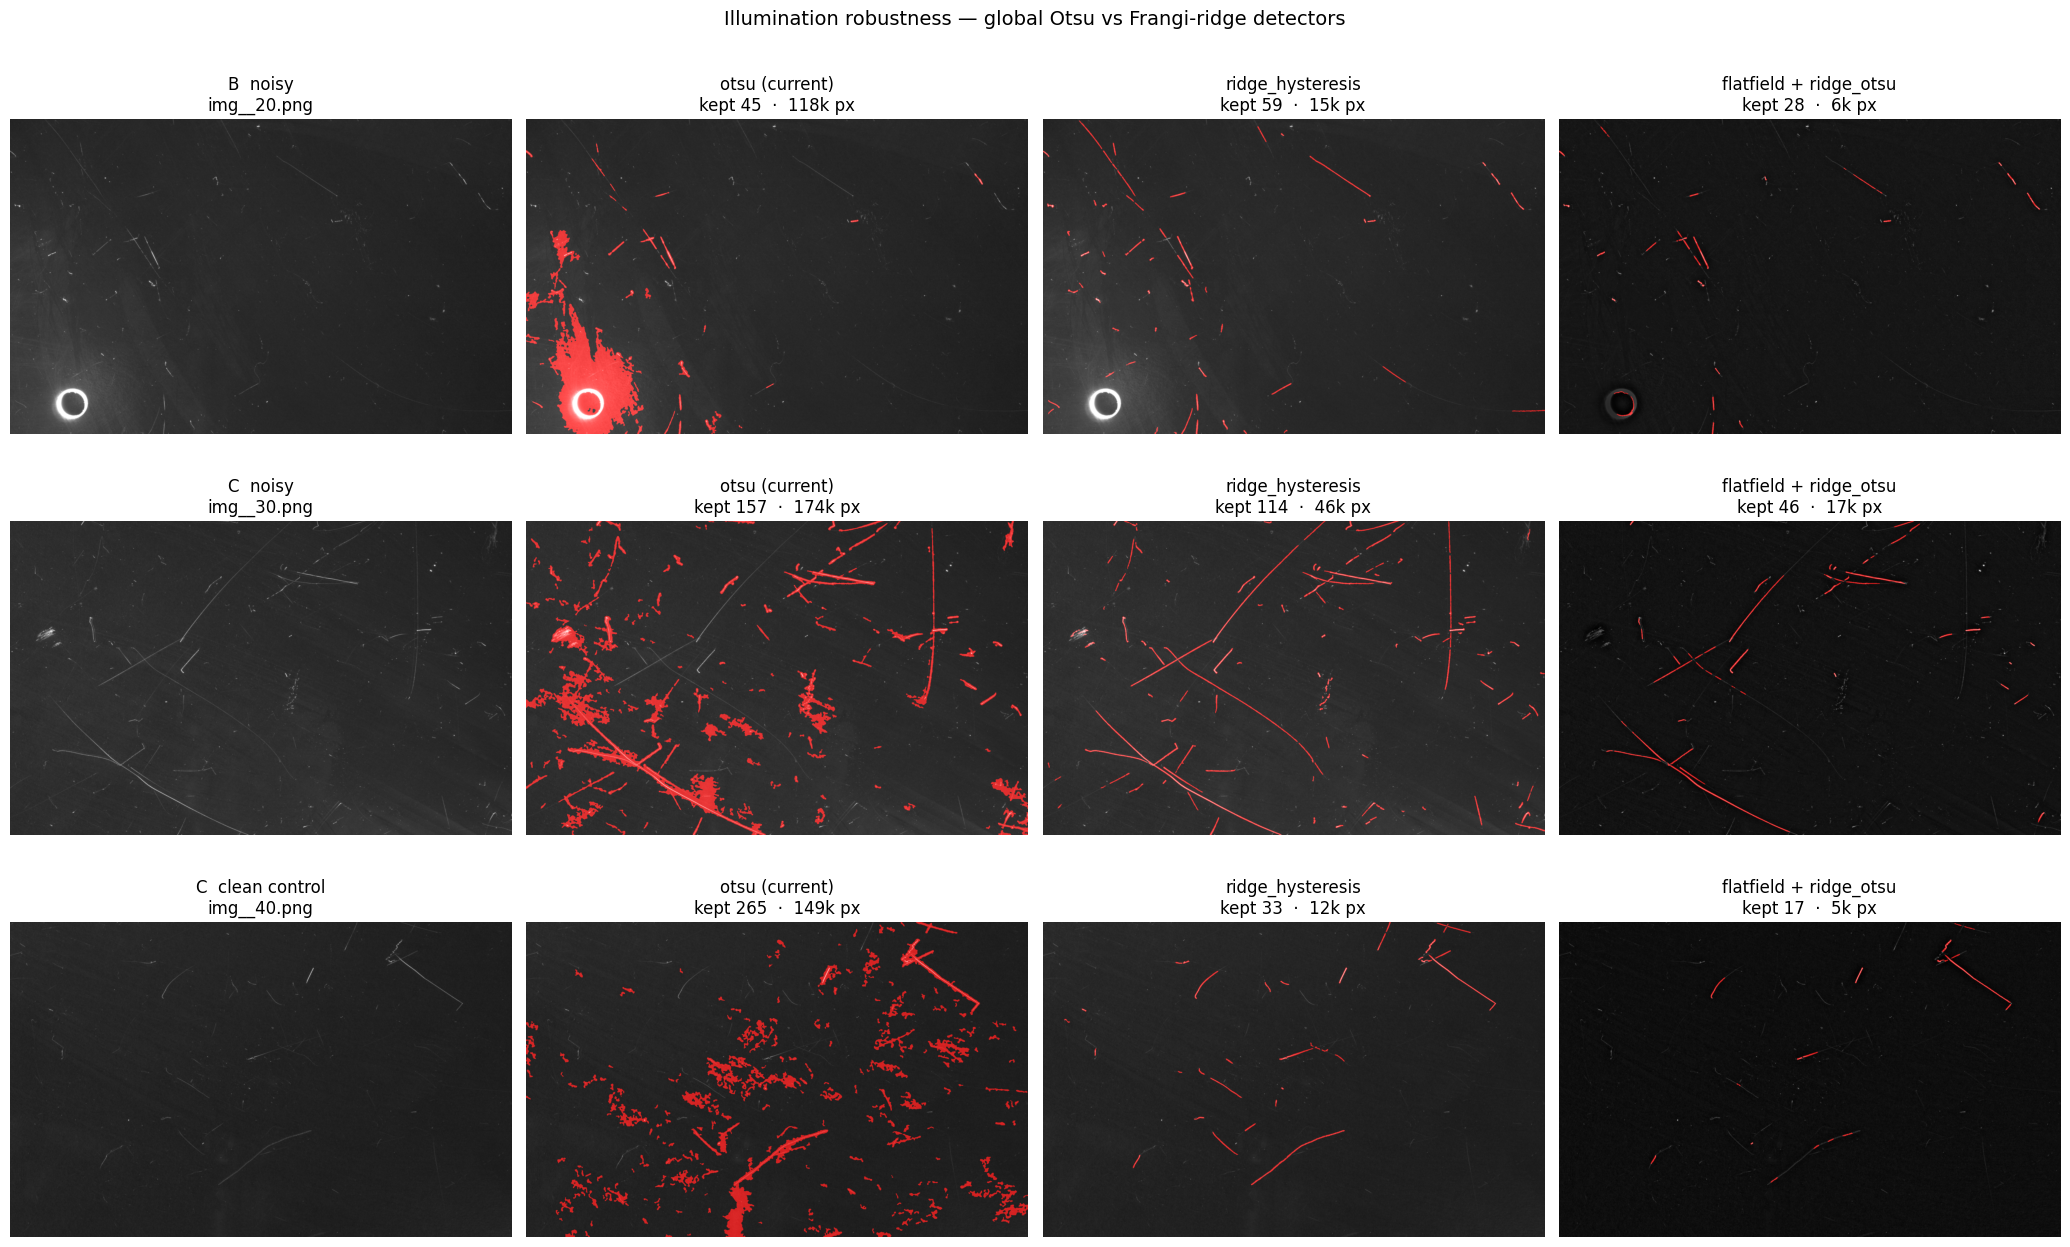

In [91]:
from dataclasses import replace


def flatfield_gray(gray: np.ndarray, ksize: int = 101) -> np.ndarray:
    """Homomorphic-style illumination correction: divide out the smooth lighting field.

    Estimate the illumination L as a heavy Gaussian blur (kernel >> scratch width, so thin
    scratches don't bias it), then flat = gray / L. DIVISION (not subtraction) cancels the
    MULTIPLICATIVE vignetting / cloudy brightness field that makes global Otsu flood on
    glasses like B/img__13. Rescaled back to uint8 so the rest of the pipeline is unchanged.
    """
    k = ksize if ksize % 2 == 1 else ksize + 1
    L = np.maximum(cv.GaussianBlur(gray, (k, k), 0).astype(np.float32), 1.0)
    flat = gray.astype(np.float32) / L
    return cv.normalize(flat, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)


def _final_overlay_for(img_gray: np.ndarray, p: Params, alpha: float = 0.7):
    """Run the back half of the pipeline and return (overlay_bgr, kept_count, final_px)."""
    stages    = preprocess(img_gray, p)
    candidate = candidate_mask(stages, p)
    final, df = filter_components(morphology_clean(candidate, p), p)
    ov = overlay_mask(img_gray, final, alpha=alpha)
    return ov, int(df.kept.sum()), int((final > 0).sum())


def compare_illumination(picks, p=None, ff_ksize=101):
    """One row per image: [ original | current Otsu | ridge_hysteresis | flat-field + ridge_otsu ].

    Lets you judge BOTH noise suppression (does the flooding disappear on the mottled
    glasses?) and recall (do the real scratches survive?) on the worst images plus a
    clean control, side by side. The Frangi-ridge columns key on line *shape* via Hessian
    eigenvalue ratios, so they are largely brightness-invariant; the flat-field column
    additionally removes the low-frequency lighting field before detection.

    NOTE: the 'otsu' / 'ridge_*' columns are hard-coded here so this stays a fixed A/B/C
    comparison regardless of what P.threshold_method is currently set to. `p` only
    supplies the OTHER knobs (frangi sigmas, hysteresis cutoffs, component gates).
    """
    p = P if p is None else p   # read the CURRENT global P, not a stale def-time copy
    variants = [
        ('otsu (current)',         lambda g: (g,                          replace(p, threshold_method='otsu'))),
        ('ridge_hysteresis',       lambda g: (g,                          replace(p, threshold_method='ridge_hysteresis'))),
        ('flatfield + ridge_otsu', lambda g: (flatfield_gray(g, ff_ksize), replace(p, threshold_method='ridge_otsu'))),
    ]
    n, ncol = len(picks), 1 + len(variants)
    fig, axes = plt.subplots(n, ncol, figsize=(5.2 * ncol, 4.3 * n))
    axes = np.atleast_2d(axes)
    for r, (label, path) in enumerate(picks):
        gray = load_gray(path)
        show(gray, f'{label}\n{path.name}', axes[r, 0])
        for c, (vname, build) in enumerate(variants, start=1):
            img_in, pv = build(gray)
            ov, kept, fpx = _final_overlay_for(img_in, pv)
            axes[r, c].imshow(cv.cvtColor(ov, cv.COLOR_BGR2RGB))
            axes[r, c].set_title(f'{vname}\nkept {kept}  ·  {fpx // 1000}k px')
            axes[r, c].set_axis_off()
    fig.suptitle('Illumination robustness — global Otsu vs Frangi-ridge detectors', y=1.002, fontsize=14)
    plt.tight_layout(); plt.show()


# Worst (flooded) images + one clean control. Swap in your own problem cases.
_tg = list_glass_images(DATASET_DIR / 'train' / 'images')
def _pick(g, name): return next(pp for pp in _tg[g] if pp.name == name)
compare_illumination([
    ('B  noisy',          _pick('B', 'img__20.png')),
    ('C  noisy',          _pick('C', 'img__30.png')),
    ('C  clean control',  _pick('C', 'img__40.png')),
])

In [ ]:
def process_split(images_dir: Path, masks_dir: Path, p: Params, every: int = 25) -> pd.DataFrame:
    """Run build_mask over every PNG under images_dir, saving each binary mask to the
    MIRRORED path under masks_dir.

    e.g. train/images/A-<ts>/A/img__1.png  ->  train/masks/A-<ts>/A/img__1.png
    so the image and mask folder trees stay identical (same relative path + filename),
    which is the pairing contract §10's tiling/splitting code relies on.

    Returns one QA row per image (glass label, scratch pixel count, components kept).
    """
    rows = []
    paths = sorted(images_dir.rglob('*.png'))
    for i, src in enumerate(paths, 1):
        img = load_gray(src)
        res = build_mask(img, p)
        rel     = src.relative_to(images_dir)
        out_dir = (masks_dir / rel).parent
        out_dir.mkdir(parents=True, exist_ok=True)
        save_mask(res['final'], src, out_dir)        # writes out_dir/src.name, {0,255} uint8
        rows.append(dict(glass=rel.parts[0].split('-')[0], name=src.name,
                         scratch_px=int((res['final'] > 0).sum()),
                         kept=int(res['components'].kept.sum())))
        if i % every == 0 or i == len(paths):
            print(f'  {images_dir.parent.name}: {i}/{len(paths)}')
    return pd.DataFrame(rows)


# Apply the pipeline to every train + val image and save the masks. Heavy: ~550 images
# through Frangi (a few minutes). Comment out while still tuning Params on the QA above.
train_summary = process_split(DATASET_DIR / 'train' / 'images', DATASET_DIR / 'train' / 'masks', P)
val_summary   = process_split(DATASET_DIR / 'val'   / 'images', DATASET_DIR / 'val'   / 'masks', P)

summary_all = pd.concat([train_summary.assign(split='train'),
                         val_summary.assign(split='val')], ignore_index=True)
print(f'\nsaved {len(summary_all)} masks')
summary_all.groupby(['split', 'glass'])[['scratch_px', 'kept']].agg(['mean', 'median']).round(0)